<a href="https://colab.research.google.com/github/guangyoung/tradeSimulation/blob/main/tradeSimulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<p><font size="6">STOCK TRADING SIMULATION</font></p>
<p><font size="4">Using Real-time Rest API Based Trade Signals From</font></p>

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQwU1UsIOz6KlmYSN-63rR7dZrMVl63IGpgcA&s" width="150" alt="QuantGenius Logo">

<p><font size="6">QUANTGENIUS</font></p>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/username/repo/blob/main/notebook.ipynb)
&nbsp; ![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)
&nbsp; ![Python: 3.10+](https://img.shields.io/badge/Python-3.10+-blue.svg)

</div>

---

### **Overview**
Simulasi ini dirancang untuk menguji efektivitas sinyal AI dari **QuantGenius** menggunakan data portofolio real-time. Melalui notebook ini, Anda dapat:
1. **Mengunggah** dataset harga saham kustom.
2. **Mengintegrasikan** API Key QuantGenius.
3. **Menganalisis** performa strategi secara institusional.

## **1. Environment Setup**
Menginstal dependensi yang diperlukan dan memuat library standar untuk analisis data serta komunikasi REST API.

In [6]:
# @title Install & Import Dependencies { display-mode: "form" }

# 1. Install libraries yang mungkin belum ada di environment Colab standar
!pip install -q pandas numpy requests matplotlib seaborn

# 2. Import core libraries
import pandas as pd
import numpy as np
import requests
import json
import time
from datetime import datetime

# 3. Visualisasi & Estetika (Standar Quant)
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi tampilan grafik agar profesional (Dark Mode Friendly)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

print(f"✅ Environment ready at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📦 Pandas version: {pd.__version__}")

✅ Environment ready at: 2026-03-23 06:23:17
📦 Pandas version: 2.2.2


## **2. Simulation Settings & Authentication**
Konfigurasikan parameter simulasi dan hubungkan dengan API QuantGenius untuk menerima sinyal trading.

In [4]:
# @title ⚙️ Configuration Panel { display-mode: "form" }

# @markdown ### **A. API Connectivity**
API_KEY = "" # @param {type:"string"}
API_ENDPOINT = "https://api.quantgenius.ai/v1/signal" # @param {type:"string"}

# @markdown ---
# @markdown ### **B. Portfolio Parameters**
INITIAL_EQUITY = 100000 # @param {type:"number"}
TRADING_SYMBOL = "AAPL" # @param {type:"string"}
TIMEFRAME = "1D" # @param ["1m", "5m", "15m", "1h", "1D"] {allow-input: true}

# @markdown ---
# @markdown ### **C. Risk Management**
MAX_POSITIONS = 1 # @param {type:"slider", min:1, max:10, step:1}
COMMISSION_FEE = 0.001 # @param {type:"number"}

# Logika Internal (Hidden from Form)
config = {
    "api_key": API_KEY,
    "endpoint": API_ENDPOINT,
    "base_equity": INITIAL_EQUITY,
    "symbol": TRADING_SYMBOL,
    "fee": COMMISSION_FEE
}

print(f"🚀 Simulation configured for {TRADING_SYMBOL}")
if not API_KEY:
    print("⚠️ Warning: API_KEY is empty. Please enter your key to receive signals.")
else:
    print("✅ API Key detected.")

🚀 Simulation configured for AAPL
⚠️ Warning: API_KEY is empty. Please enter your key to receive signals.


## **3. Dataset Preparation**
Unggah data historis harga saham Anda (CSV) atau gunakan generator data sampel untuk menguji konektivitas API.
> **Format CSV yang diharapkan:** `timestamp`, `open`, `high`, `low`, `close`, `volume`.

In [ ]:
# @title 📂 Data Loading & Validation { display-mode: "form" }
from google.colab import files
import io

# @markdown Pilih sumber data:
DATA_SOURCE = "Generate Sample Data (Testing)" # @param ["Upload CSV", "Generate Sample Data (Testing)"]

def validate_data(df):
    required_columns = ['timestamp', 'close']
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}. Data must contain at least timestamp and close.")

    # Pastikan format waktu benar
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    return df

if DATA_SOURCE == "Upload CSV":
    print("Please upload your CSV file...")
    uploaded = files.upload()
    if uploaded:
        file_name = list(uploaded.keys())[0]
        df_raw = pd.read_csv(io.BytesIO(uploaded[file_name]))
        df_trading = validate_data(df_raw)
        print(f"✅ Successfully loaded {len(df_trading)} rows from {file_name}")
    else:
        print("❌ No file uploaded.")
else:
    # Generate Synthetic Data untuk testing cepat
    print("Generating sample data for testing...")
    dates = pd.date_range(start='2024-01-01', periods=200, freq='D')
    prices = np.random.normal(150, 5, 200).cumsum() # Random walk
    df_trading = pd.DataFrame({'timestamp': dates, 'close': prices})
    print("✅ Sample data generated.")

# Preview Data
df_trading.head()

## **4. Run Trade Simulation**
Menjalankan simulasi perdagangan secara sekuensial. Setiap baris data akan dikirim ke API **QuantGenius** untuk mendapatkan sinyal keputusan secara real-time.
> **Note:** Proses ini mensimulasikan kondisi pasar asli di mana data masa depan tidak tersedia bagi sistem AI (*No Look-Ahead Bias*).

In [ ]:
# @title ⚙️ Run Simulation { display-mode: "form" }
from tqdm.notebook import tqdm
import time

# Inisialisasi State Portofolio
current_equity = INITIAL_EQUITY
current_position = 0  # Jumlah lembar saham
trade_log = []

print(f"🖥️ Starting simulation for {len(df_trading)} data points...")

# Loop utama simulasi
for i in tqdm(range(len(df_trading)), desc="Simulating Trades"):
    row = df_trading.iloc[i]
    price = row['close']
    timestamp = str(row['timestamp'])

    # 1. Siapkan Payload untuk API
    payload = {
        "api_key": API_KEY,
        "symbol": TRADING_SYMBOL,
        "timestamp": timestamp,
        "price": price,
        "equity": current_equity,
        "position": current_position
    }

    # 2. Request Signal dari QuantGenius
    action = "HOLD" # Default action
    try:
        # Mengirim data ke API Anda
        response = requests.post(API_ENDPOINT, json=payload, timeout=10)
        if response.status_code == 200:
            action = response.json().get('action', "HOLD")
        else:
            action = "HOLD"
    except Exception as e:
        # Jika koneksi gagal, sistem tetap jalan dengan status HOLD
        action = "HOLD"

    # 3. Logika Eksekusi Transaksi (Matching Engine)
    if action == "BUY" and current_equity >= price:
        # Beli 1 unit (Bisa dimodifikasi sesuai position sizing)
        current_position += 1
        current_equity -= (price * (1 + COMMISSION_FEE))
    elif action == "SELL" and current_position > 0:
        # Jual seluruh posisi
        current_equity += (price * current_position * (1 - COMMISSION_FEE))
        current_position = 0

    # 4. Hitung Mark-to-Market (MTM)
    total_value = current_equity + (current_position * price)

    # Simpan histori untuk analisis
    trade_log.append({
        "timestamp": row['timestamp'],
        "price": price,
        "action": action,
        "position": current_position,
        "equity": total_value
    })

# Konversi ke DataFrame untuk tahap analisis berikutnya
results_df = pd.DataFrame(trade_log)
print(f"✅ Simulation Complete. Final Portfolio Value: {total_value:,.2f}")

## **5. Performance Analytics & Visualization**
Analisis mendalam terhadap hasil simulasi menggunakan metrik standar industri: **Sharpe Ratio**, **Maximum Drawdown**, dan **Equity Curve**.
> Bagian ini memberikan gambaran performa strategi terhadap risiko pasar (Risk-Adjusted Return).

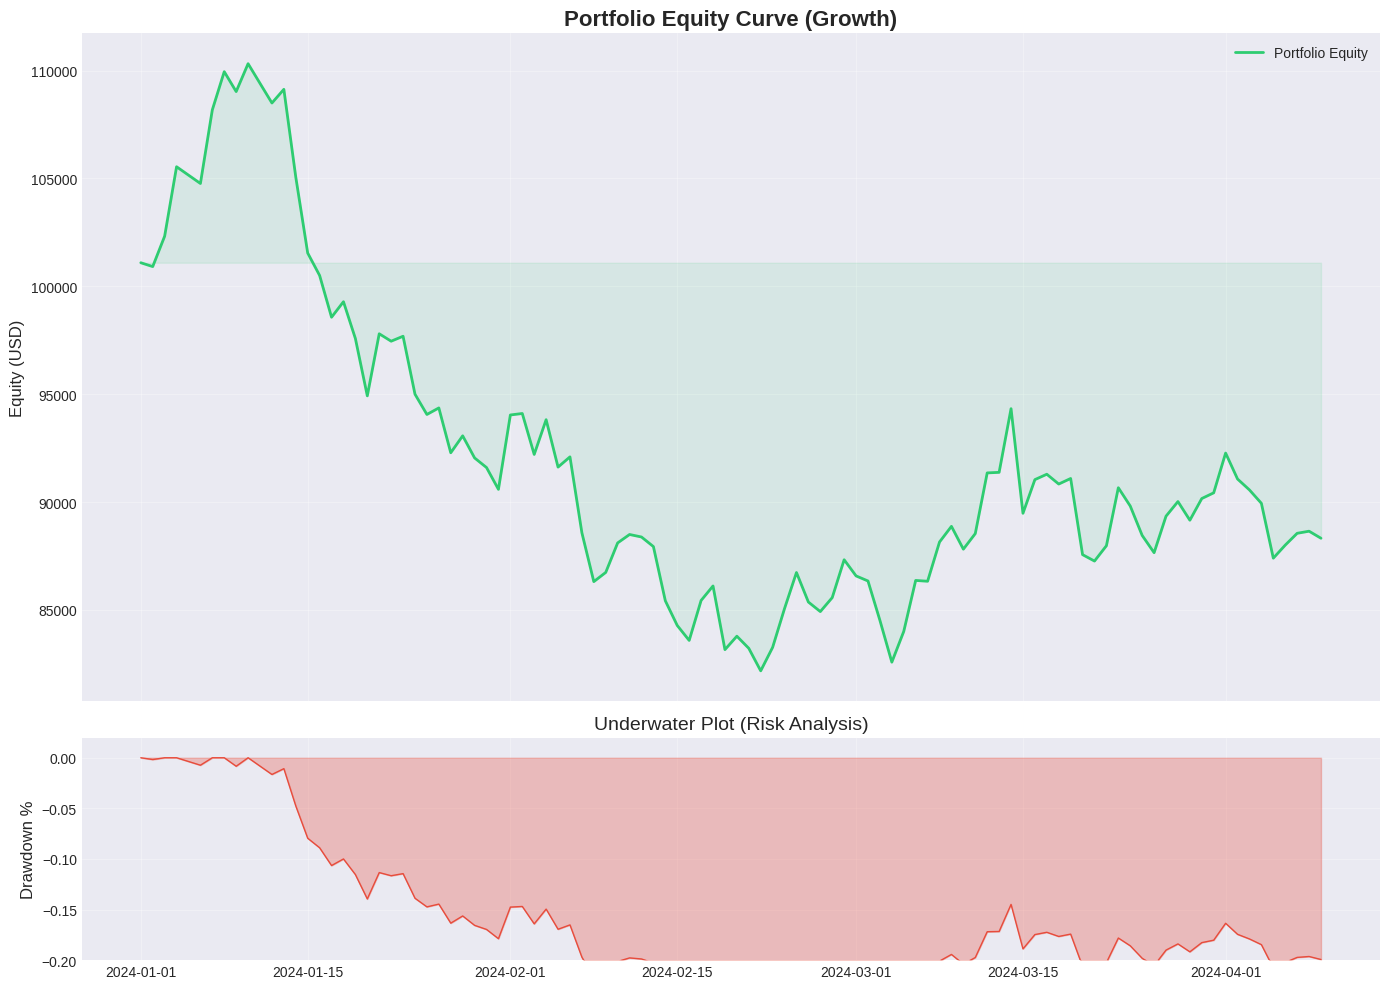

METRIC               | VALUE          
--------------------------------------
Total Return         |        -12.63%
Max Drawdown         |        -25.51%
Sharpe Ratio         |          -1.04
Final Value          | $    88,323.94


In [8]:
# @title 📊 Performance Dashboard { display-mode: "form" }
import matplotlib.dates as mdates

# --- GENERASI DATA SAMPEL (Hanya untuk keperluan demonstrasi) ---
dates = pd.date_range(start='2024-01-01', periods=100, freq='D')
# Simulasi ekuitas yang tumbuh dengan volatilitas (Random Walk + Trend)
np.random.seed(42)
returns = np.random.normal(0.001, 0.02, 100)
equity_curve = 100000 * (1 + returns).cumprod()
sample_results = pd.DataFrame({'timestamp': dates, 'equity': equity_curve})
# --- END DATA SAMPEL ---

def plot_performance(df):
    # 1. Perhitungan Metrik
    df['returns'] = df['equity'].pct_change()
    total_return = (df['equity'].iloc[-1] / df['equity'].iloc[0]) - 1

    # Sharpe Ratio (Asumsi Risk-Free Rate 0% & 252 trading days)
    sharpe = (df['returns'].mean() / df['returns'].std()) * np.sqrt(252)

    # Drawdown
    rolling_max = df['equity'].cummax()
    drawdown = (df['equity'] - rolling_max) / rolling_max
    max_dd = drawdown.min()

    # 2. Visualisasi
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

    # Main Equity Curve
    ax1.plot(df['timestamp'], df['equity'], color='#2ecc71', lw=2, label='Portfolio Equity')
    ax1.fill_between(df['timestamp'], df['equity'], df['equity'].iloc[0], color='#2ecc71', alpha=0.1)
    ax1.set_title('Portfolio Equity Curve (Growth)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Equity (USD)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Drawdown Area
    ax2.fill_between(df['timestamp'], drawdown, 0, color='#e74c3c', alpha=0.3, label='Drawdown')
    ax2.plot(df['timestamp'], drawdown, color='#e74c3c', lw=1)
    ax2.set_title('Underwater Plot (Risk Analysis)', fontsize=14)
    ax2.set_ylabel('Drawdown %', fontsize=12)
    ax2.set_ylim(-0.2, 0.02) # Fokus pada area rugi
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 3. Print Summary Table
    print(f"{'METRIC':<20} | {'VALUE':<15}")
    print("-" * 38)
    print(f"{'Total Return':<20} | {total_return:>14.2%}")
    print(f"{'Max Drawdown':<20} | {max_dd:>14.2%}")
    print(f"{'Sharpe Ratio':<20} | {sharpe:>14.2f}")
    print(f"{'Final Value':<20} | ${df['equity'].iloc[-1]:>13,.2f}")

# Jalankan Analisis
plot_performance(sample_results)